# Project Name: Premium prediction for Health insurance

# Step-1: Data Loading + EDA + Data Cleaning

In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("premium_rest.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,25L - 40L,27,No Disease,Bronze,7452
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,Gold,29496
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,Bronze,10957
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076


In [3]:
df['Genetical_Risk'] = 0
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,25L - 40L,27,No Disease,Bronze,7452,0
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,Gold,29496,0
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,Bronze,10957,0
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076,0


# EDA + Data cleaning

In [4]:
df.shape

(32437, 14)

In [5]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number of dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

In [8]:
df.columns = df.columns.str.replace(" ", "_")

In [9]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

# Handling of Null values

In [10]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [11]:
df.dropna(inplace = True)

In [12]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

# Handling Duplicate values

In [13]:
print(df.duplicated().sum())

0


In [14]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,32419.000000,32419.000000,32419.000000,32419.000000,32419.0
mean,41.958759,2.251242,23.220210,19885.373454,0.0
std,13.791997,1.468032,24.457152,7541.154293,0.0
min,25.000000,-3.000000,1.000000,3508.000000,0.0
25%,32.000000,1.000000,7.000000,13996.000000,0.0
50%,41.000000,2.000000,17.000000,19698.000000,0.0
75%,51.000000,3.000000,32.000000,25739.500000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


## Resolve Negative value in number of dependent column

In [15]:
df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1951,34,Female,Southeast,Married,-1,Underweight,Regular,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Silver,22995,0
2468,41,Male,Southwest,Married,-1,Obesity,Regular,Salaried,10L - 25L,21,Diabetes,Silver,22766,0
3823,56,Male,Southwest,Married,-3,Normal,Occasional,Salaried,10L - 25L,16,Thyroid,Bronze,11979,0
4239,26,Male,Southeast,Married,-1,Obesity,Occasional,Freelancer,25L - 40L,27,No Disease,Silver,18269,0
5054,25,Male,Northwest,Unmarried,-1,Underweight,No Smoking,Salaried,10L - 25L,13,No Disease,Bronze,7234,0
5312,37,Male,Northwest,Married,-1,Overweight,Regular,Self-Employed,<10L,8,Diabetes,Bronze,13664,0
6410,42,Female,Southeast,Unmarried,-3,Overweight,Regular,Self-Employed,<10L,8,Diabetes & Heart disease,Bronze,17779,0
7684,50,Female,Northwest,Married,-3,Normal,Occasional,Salaried,<10L,4,Diabetes & High blood pressure,Silver,21957,0
7825,47,Male,Northwest,Unmarried,-3,Overweight,Occasional,Self-Employed,10L - 25L,19,No Disease,Gold,27457,0
8183,39,Male,Southwest,Unmarried,-1,Overweight,Occasional,Self-Employed,25L - 40L,40,High blood pressure,Silver,18406,0


In [16]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-1, -3])

In [17]:
# By mistage customer write +3 to -3 and +1 to -1
df.number_of_dependants = df.number_of_dependants.abs()

In [18]:
df.number_of_dependants.unique()

array([0, 2, 3, 4, 1, 5])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32419 entries, 0 to 32436
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    32419 non-null  int64 
 1   gender                 32419 non-null  object
 2   region                 32419 non-null  object
 3   marital_status         32419 non-null  object
 4   number_of_dependants   32419 non-null  int64 
 5   bmi_category           32419 non-null  object
 6   smoking_status         32419 non-null  object
 7   employment_status      32419 non-null  object
 8   income_level           32419 non-null  object
 9   income_lakhs           32419 non-null  int64 
 10  medical_history        32419 non-null  object
 11  insurance_plan         32419 non-null  object
 12  annual_premium_amount  32419 non-null  int64 
 13  genetical_risk         32419 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 3.7+ MB


# Handling of Outliers

In [20]:
numeric_columns = df.select_dtypes(include = "int64").columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

## Box plot for Outliers

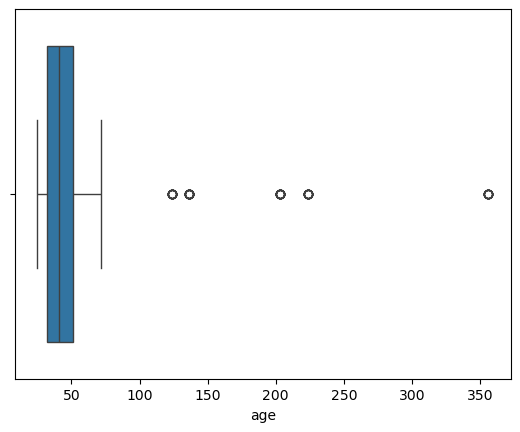

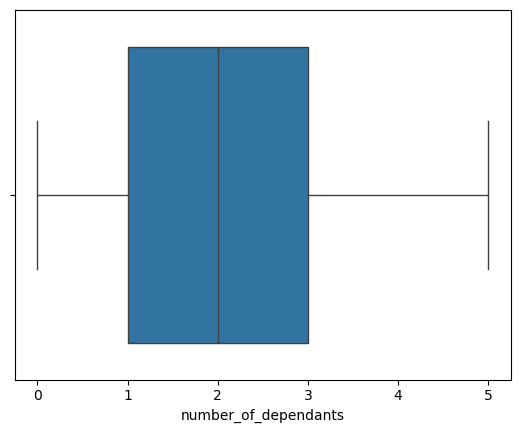

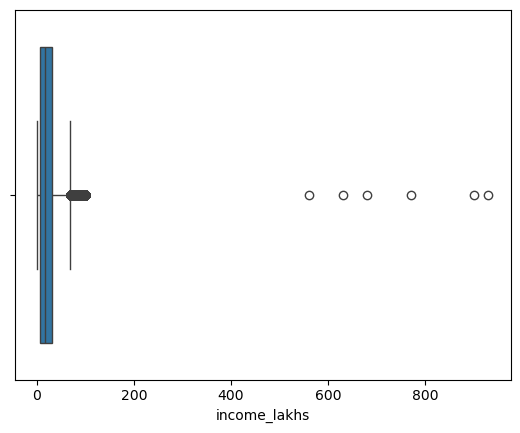

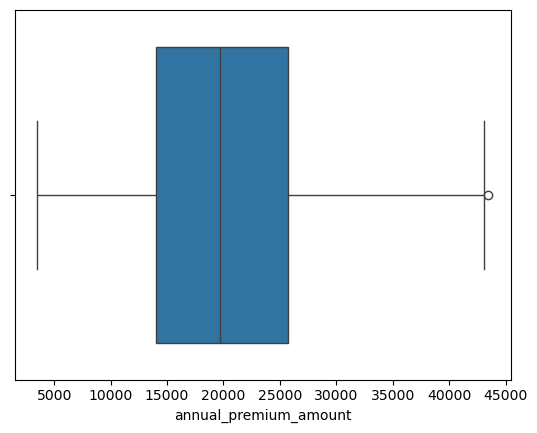

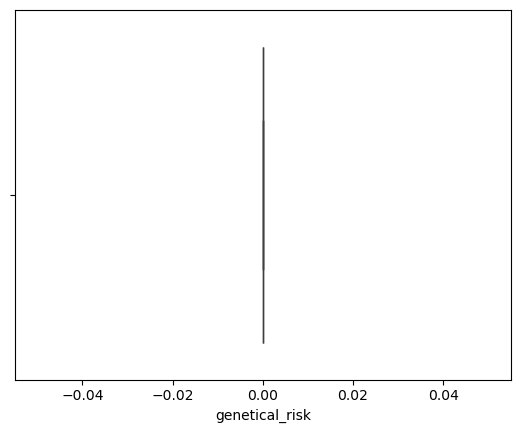

In [21]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

### Handling of outlier in age column

In [22]:
Q1 = np.percentile(df.age, 25)
Q3 = np.percentile(df.age, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

32.0
51.0
79.5


In [23]:
df[df.age > 100].count()

age                      58
gender                   58
region                   58
marital_status           58
number_of_dependants     58
bmi_category             58
smoking_status           58
employment_status        58
income_level             58
income_lakhs             58
medical_history          58
insurance_plan           58
annual_premium_amount    58
genetical_risk           58
dtype: int64

In [24]:
df[df.age > 100]['age'].unique()

array([224, 124, 136, 203, 356])

In [25]:
df[df.age > 100]['age'].value_counts()

age
136    15
203    13
124    11
224    10
356     9
Name: count, dtype: int64

In [26]:
median_age = df.age.median()
print(median_age)

41.0


In [27]:
df.loc[df.age > 100, 'age'] = median_age

In [28]:
df[df.age > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handling outliers in income_lakhs column

In [29]:
Q1 = np.percentile(df.income_lakhs, 25)
Q3 = np.percentile(df.income_lakhs, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

7.0
32.0
69.5


In [30]:
df[df.income_lakhs > 100].count()

age                      6
gender                   6
region                   6
marital_status           6
number_of_dependants     6
bmi_category             6
smoking_status           6
employment_status        6
income_level             6
income_lakhs             6
medical_history          6
insurance_plan           6
annual_premium_amount    6
genetical_risk           6
dtype: int64

In [31]:
df.shape

(32419, 14)

In [32]:
df[df.income_lakhs > 100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1728,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692,0
5048,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010,0
5841,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848,0
6662,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945,0
22968,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115,0
26550,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926,0


In [33]:
# deleted the Outliers
df = df[df.income_lakhs <= 100]

In [34]:
df[df.income_lakhs > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [35]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,32413.000000,32413.000000,32413.000000,32413.000000,32413.0
mean,41.677074,2.257150,23.086601,19884.070774,0.0
std,11.652197,1.458819,22.324760,7540.875715,0.0
min,25.000000,0.000000,1.000000,3508.000000,0.0
25%,32.000000,1.000000,7.000000,13995.000000,0.0
50%,41.000000,2.000000,17.000000,19692.000000,0.0
75%,51.000000,3.000000,32.000000,25733.000000,0.0
max,72.000000,5.000000,100.000000,43471.000000,0.0


## EDA & Data Cleaning on Categorical variables

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32413 entries, 0 to 32436
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    32413 non-null  int64 
 1   gender                 32413 non-null  object
 2   region                 32413 non-null  object
 3   marital_status         32413 non-null  object
 4   number_of_dependants   32413 non-null  int64 
 5   bmi_category           32413 non-null  object
 6   smoking_status         32413 non-null  object
 7   employment_status      32413 non-null  object
 8   income_level           32413 non-null  object
 9   income_lakhs           32413 non-null  int64 
 10  medical_history        32413 non-null  object
 11  insurance_plan         32413 non-null  object
 12  annual_premium_amount  32413 non-null  int64 
 13  genetical_risk         32413 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 3.7+ MB


In [37]:
categorical_columns = df.select_dtypes(include = "object").columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [38]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


In [39]:
df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_19380\1074089374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})


In [40]:
df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

# Step-2 : Feature Engineering

### convert the Categorical variable into Numerical variables

In [41]:
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

### Ordinal Encoding: Rank or Order 'income_level', 'insurance_plan'

In [42]:
from sklearn.preprocessing import OrdinalEncoder

In [43]:
encoder = OrdinalEncoder(categories = [['Bronze', 'Silver', 'Gold']])
df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_19380\1274939803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])


In [44]:
df.insurance_plan = df.insurance_plan.astype('int64')

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_19380\355962698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = df.insurance_plan.astype('int64')


In [45]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,0,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,0,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,1,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,2,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,0,15610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,25L - 40L,27,No Disease,0,7452,0
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,2,29496,0
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,0,10957,0
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,2,27076,0


In [46]:
encoder = OrdinalEncoder(categories = [['<10L', '10L - 25L', '25L - 40L', '> 40L']])
df.income_level = encoder.fit_transform(df[['income_level']])

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_19380\2938848440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.income_level = encoder.fit_transform(df[['income_level']])


In [47]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,0.0,6,Diabetes,0,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,0.0,6,Diabetes,0,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,1.0,20,High blood pressure,1,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,3.0,77,No Disease,2,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,1.0,14,Diabetes,0,15610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,Female,Northwest,Unmarried,2,Underweight,No Smoking,Salaried,2.0,27,No Disease,0,7452,0
32433,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,1.0,16,Diabetes & Thyroid,2,29496,0
32434,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,0.0,4,No Disease,0,10957,0
32435,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,3.0,82,Thyroid,2,27076,0


# Use Label encoding to convert categorical column to numerical number

In [48]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : [0. 1. 3. 2.]
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : [0 1 2]


In [49]:
# Use label encoding when their is NO RANKING between the classes in the data

from sklearn.preprocessing import LabelEncoder

In [50]:
encoder = LabelEncoder()
df.region = encoder.fit_transform(df.region)

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_19380\166564218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.region = encoder.fit_transform(df.region)


In [51]:
encoder = LabelEncoder()
df.bmi_category = encoder.fit_transform(df.bmi_category)

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_19380\744827222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.bmi_category = encoder.fit_transform(df.bmi_category)


In [52]:
# One hot encoding: Convert categorical data to numerical
# When number of sub-categories are less
df = pd.get_dummies(df, columns = ['gender', 'marital_status', 'smoking_status', 'employment_status'], drop_first = True, dtype = int)

In [53]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,1,0,0,0.0,6,Diabetes,0,9053,0,1,1,0,0,1,0
1,29,2,2,1,0.0,6,Diabetes,0,16339,0,0,0,0,1,1,0
2,49,0,2,0,1.0,20,High blood pressure,1,18164,0,0,0,0,0,0,1
3,30,2,3,0,3.0,77,No Disease,2,20303,0,0,0,0,0,1,0
4,56,0,3,1,1.0,14,Diabetes,0,15610,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,1,2,3,2.0,27,No Disease,0,7452,0,0,1,0,0,1,0
32433,40,2,0,2,1.0,16,Diabetes & Thyroid,2,29496,0,0,1,0,1,1,0
32434,37,1,0,1,0.0,4,No Disease,0,10957,0,0,1,0,0,1,0
32435,47,2,2,0,3.0,82,Thyroid,2,27076,0,0,0,0,0,1,0


# Covert categorical column to numerical : Manually

In [54]:
df.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [55]:
risk_score = {
                'Diabetes' : 6,
                'High blood pressure' : 6,
                'Heart disease' : 8,
                'Thyroid' : 5,
                'No Disease' : 0,
                'Diabetes & High blood pressure' : 12,
                'High blood pressure & Heart disease' : 14,
                'Diabetes & Thyroid' : 11,
                'Diabetes & Heart disease' : 14
}
df.medical_history = df.medical_history.map(risk_score)

In [56]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,1,0,0,0.0,6,6,0,9053,0,1,1,0,0,1,0
1,29,2,2,1,0.0,6,6,0,16339,0,0,0,0,1,1,0
2,49,0,2,0,1.0,20,6,1,18164,0,0,0,0,0,0,1
3,30,2,3,0,3.0,77,0,2,20303,0,0,0,0,0,1,0
4,56,0,3,1,1.0,14,6,0,15610,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32432,25,1,2,3,2.0,27,0,0,7452,0,0,1,0,0,1,0
32433,40,2,0,2,1.0,16,11,2,29496,0,0,1,0,1,1,0
32434,37,1,0,1,0.0,4,0,0,10957,0,0,1,0,0,1,0
32435,47,2,2,0,3.0,82,5,2,27076,0,0,0,0,0,1,0


# Feature Scaling

In [57]:
from sklearn.preprocessing import MinMaxScaler

In [58]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk', 'gender_Male',
       'marital_status_Unmarried', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [59]:
cols_to_scale = ['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
      'gender_Male', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed']

In [60]:
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Remove the features which are related to each other

# Correaltion matrix + Heatmap

In [61]:
cm = df.corr()

<Axes: >

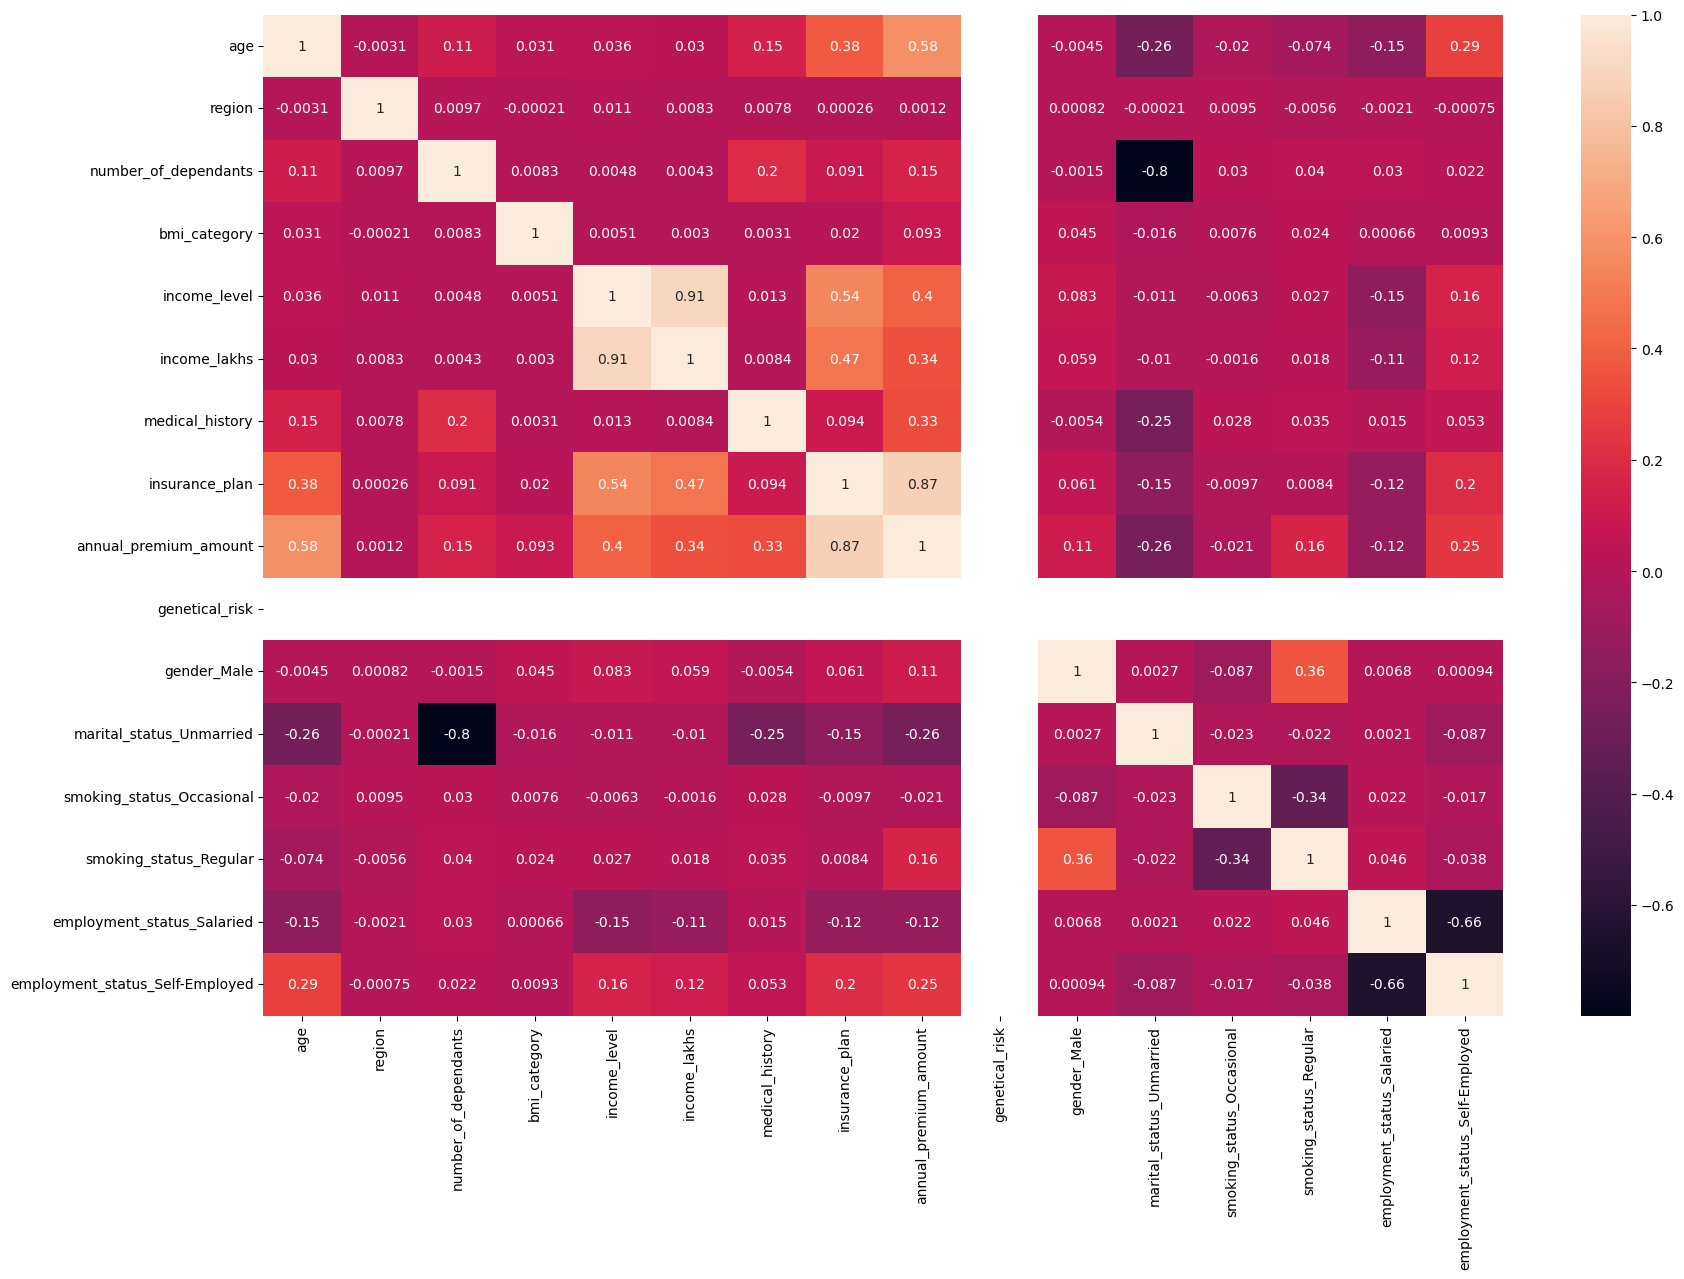

In [62]:
plt.figure(figsize = (20, 13))
sns.heatmap(cm, annot = True)

# Delete the highly correlated features : more than 80% related
 # number_of_dependents = marital_status_unmarried
# income_level = income_lakhs

# Don't delete the features which are related to target variable

In [63]:
df.drop(['marital_status_Unmarried', 'income_level'], axis = 1, inplace = True)

In [64]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'gender_Male', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

# Step-4 : Model training & downloading/saving trained model

In [65]:
# Linear regresssion
# Xgboost

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [67]:
x = df.drop("annual_premium_amount", axis = 1)
y = df.annual_premium_amount

In [68]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [69]:
linear_obj = LinearRegression()
linear_obj.fit(x_train, y_train)

LinearRegression()

In [70]:
lr_score = linear_obj.score(x_test,y_test)
print(lr_score)

0.915642553890367


In [71]:
# pip install --upgrade xgboost

In [72]:
import xgboost as xgb

In [73]:
XGB_obj = xgb.XGBRegressor()

In [74]:
# Hyper parameter tuning
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators' : [20, 30, 40, 50],
    'learning_rate' : [0.001, 0.01, 0.1, 0.5],
    'max_depth' : [3,4,5,6]
}

random_search = RandomizedSearchCV(XGB_obj, param_grid, cv = 3)

random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.001, 0.01, 0.1,
                                                          0.5],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [20, 30, 40, 50]})

In [75]:
random_search.best_score_

np.float64(0.9933054645856222)

In [76]:
# Target1: perfomance > 97%
# Target2: difference between actual premium and predicted premium < 10%

# Target2: difference between actual premium and predicted premium < 10%

In [77]:
y_pred = random_search.predict(x_test)
y_pred

array([28568.803, 22646.086, 19198.277, ..., 14251.44 , 31560.096,
       24908.02 ], dtype=float32)

In [78]:
residuals = y_pred - y_test
residual_pct = (residuals / y_test) * 100
print(residual_pct)

29825    -0.095109
29683    -1.151960
27644    -3.821064
9975      0.908365
3487      0.794175
           ...    
30902   -24.657005
22692     0.280930
20085     3.421193
32402     0.445881
12178    -2.455377
Name: annual_premium_amount, Length: 6483, dtype: float64


In [79]:
result_df = pd.DataFrame({
                            'Actual' : y_test,
                            'Predicted' : y_pred,
                            'diff' : residuals,
                            'diff_pct' : residual_pct
})

In [80]:
result_df.head(10)

,Actual,Predicted,diff,diff_pct
29825,28596,28568.802734,-27.197266,-0.095109
29683,22910,22646.085938,-263.914062,-1.151960
27644,19961,19198.277344,-762.722656,-3.821064
9975,18584,18752.810547,168.810547,0.908365
3487,26822,27035.013672,213.013672,0.794175
24570,21565,22215.130859,650.130859,3.014750
13674,15873,15480.623047,-392.376953,-2.471977
31605,20668,20612.236328,-55.763672,-0.269807
4117,20147,20597.009766,450.009766,2.233632
3106,15617,15498.581055,-118.418945,-0.758269


<Axes: xlabel='diff_pct', ylabel='Count'>

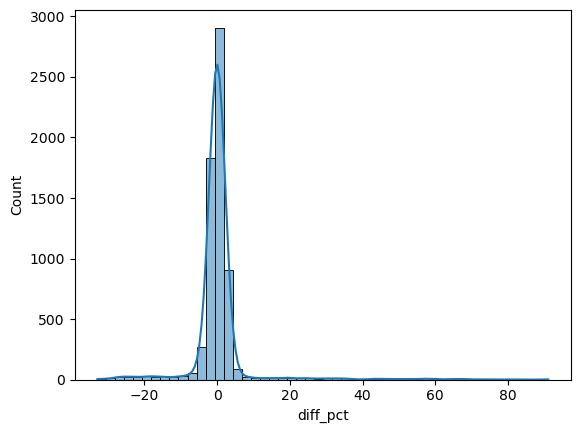

In [81]:
sns.histplot(result_df['diff_pct'], bins = 50, kde = True)

In [82]:
# extreme data 
extreame_result_df = result_df[np.abs(result_df.diff_pct > 10)]
extreame_result_df

,Actual,Predicted,diff,diff_pct
32283,8045,9218.278320,1173.278320,14.583944
12935,10984,13588.295898,2604.295898,23.709904
17962,6496,7247.147949,751.147949,11.563238
6921,6029,7268.915527,1239.915527,20.565857
25082,3590,6194.247559,2604.247559,72.541715
...,...,...,...,...
29360,5954,6566.144043,612.144043,10.281223
18670,4665,7107.977539,2442.977539,52.368222
25294,9913,11205.111328,1292.111328,13.034514
32431,4615,6927.658203,2312.658203,50.111770


In [83]:
extreame_result_df.shape

(186, 4)

In [84]:
# Calculate percentage
x_test.shape

(6483, 13)

In [85]:
(1568 / 9994) * 100

15.689413648188912

In [86]:
# 3+ year experience ML engineer

# 5% values with more than 10% difference is allowed
# But we are getting 15% records having difference more than 10%

In [87]:
# Finding complete record where extreame values exist
extreame_error_df = x_test.loc[extreame_result_df.index]
extreame_error_df.head()

,age,region,number_of_dependants,bmi_category,income_lakhs,medical_history,insurance_plan,genetical_risk,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
32283,0.0,1.000000,0.0,0.333333,0.070707,0.428571,0.0,0,1.0,1.0,0.0,1.0,0.0
12935,0.0,0.666667,0.0,1.000000,0.191919,0.000000,1.0,0,1.0,0.0,0.0,1.0,0.0
17962,0.0,0.333333,0.0,0.000000,0.393939,0.000000,0.0,0,1.0,1.0,0.0,0.0,0.0
6921,0.0,0.666667,0.0,1.000000,0.343434,0.000000,0.0,0,1.0,0.0,1.0,0.0,0.0
25082,0.0,0.000000,0.4,0.000000,0.151515,0.000000,0.0,0,1.0,0.0,0.0,1.0,0.0


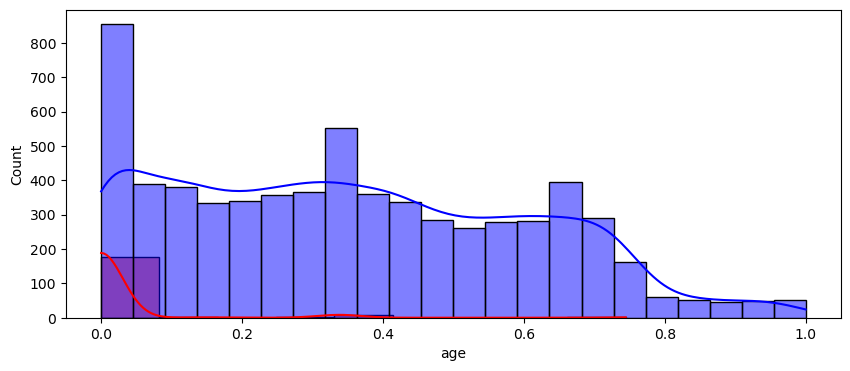

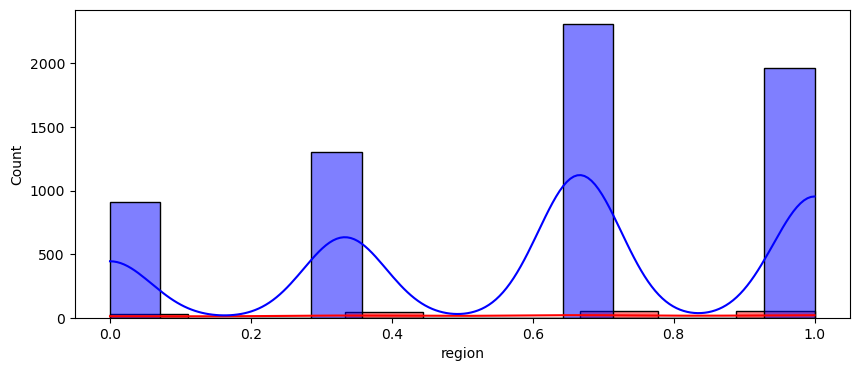

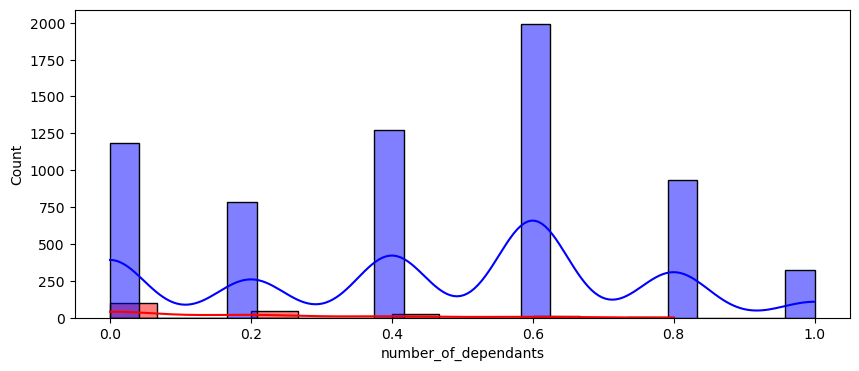

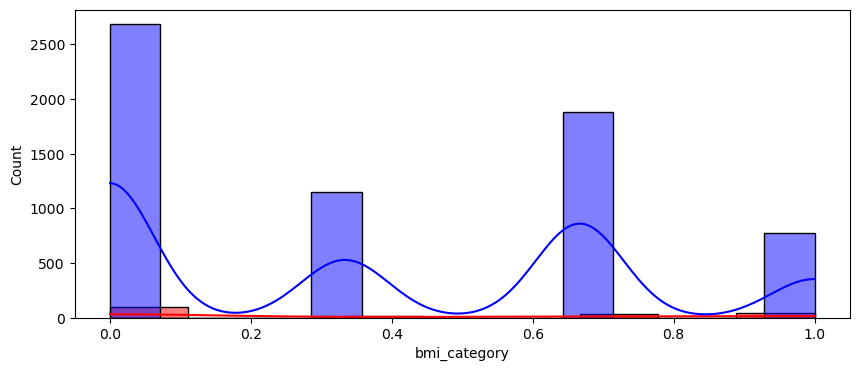

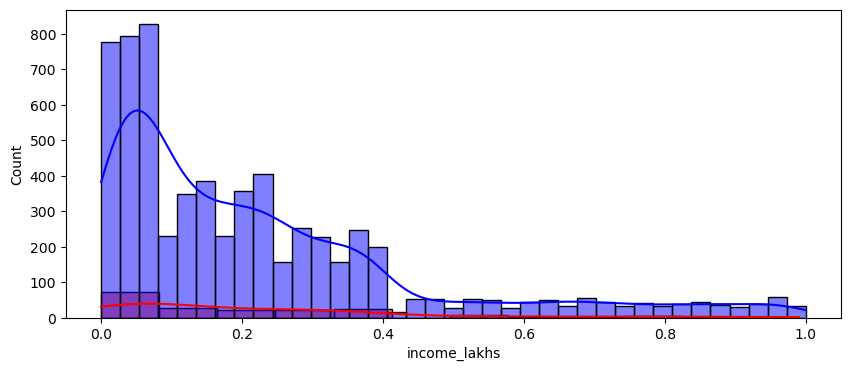

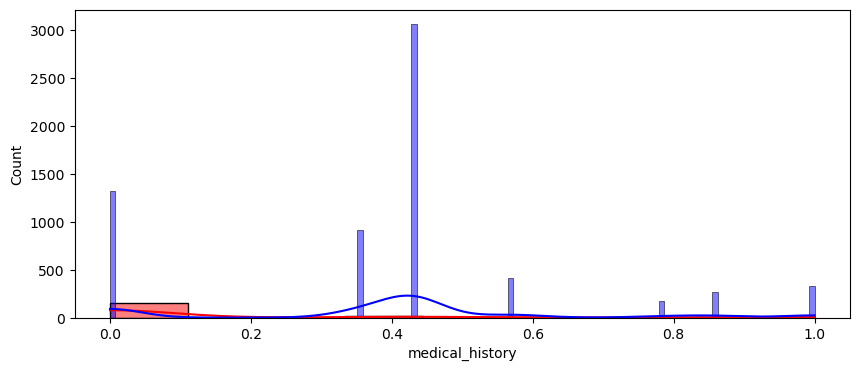

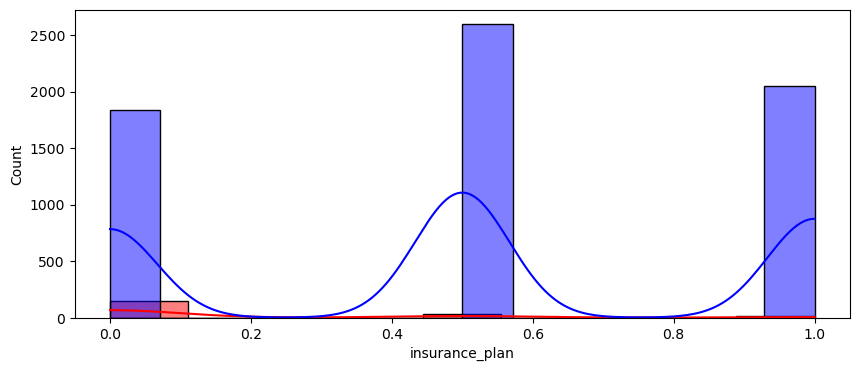

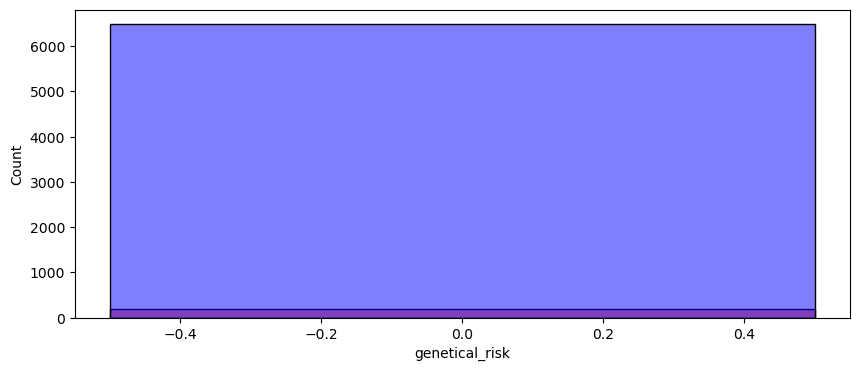

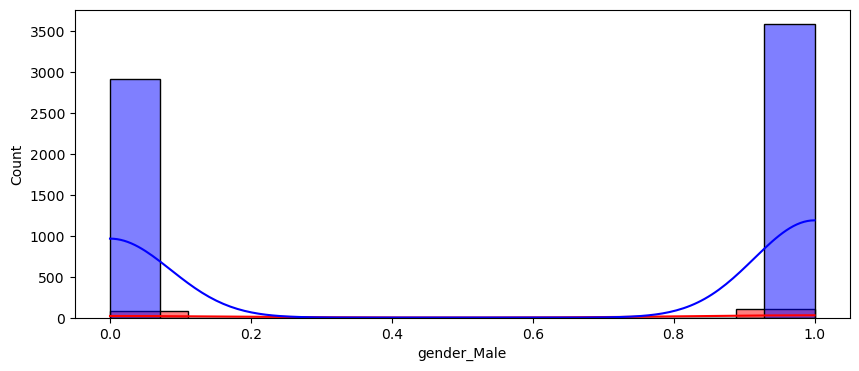

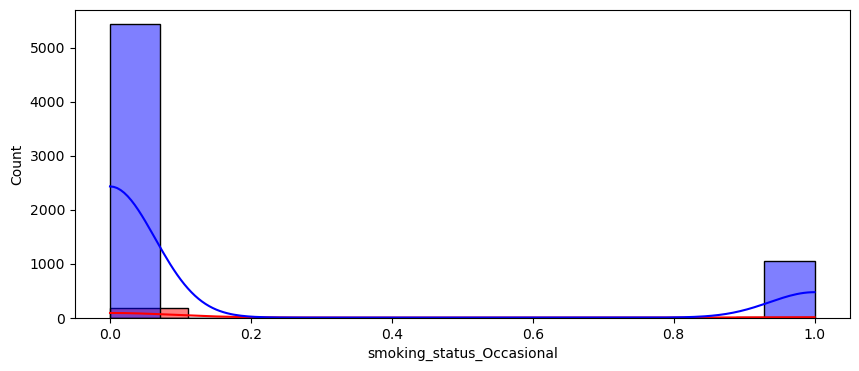

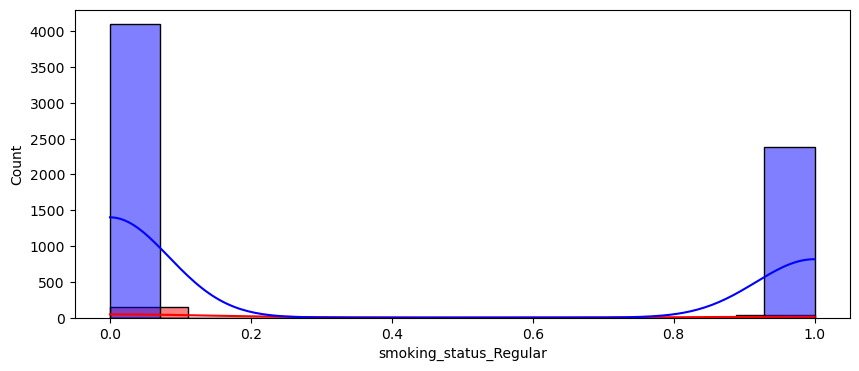

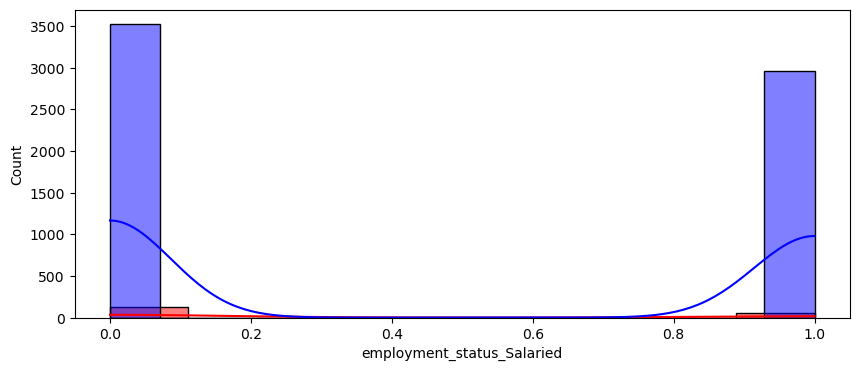

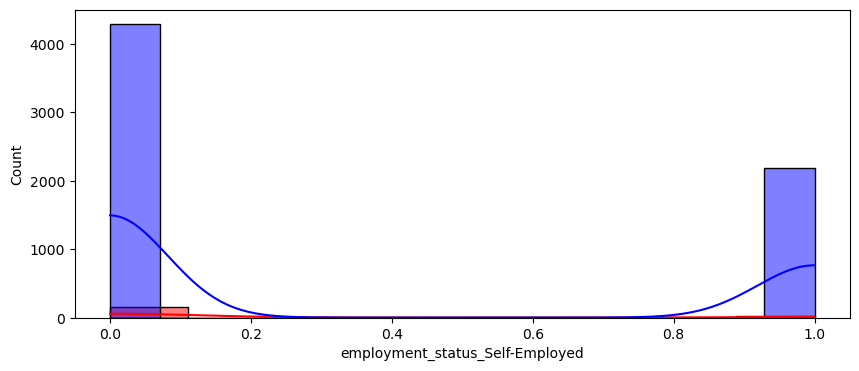

In [88]:
for feature in x_test.columns:
    plt.figure(figsize = (10,4))
    sns.histplot(extreame_error_df[feature], color = 'red', kde = True)
    sns.histplot(x_test[feature], color = 'blue', kde = True)
    plt.show()

In [89]:
x_test.shape

(6483, 13)

In [90]:
# reverse scaling
# Segmentation

# Reverse Scaling

In [91]:
# I want to find the actual value of features (not the scaled value)
# df.drop(['marital_status_Unmarried', 'income_level'], axis = 1, inplace = True)
df_reversed = pd.DataFrame()
extreame_error_df['income_level'] = -1
extreame_error_df['marital_status_Unmarried'] = -1
df_reversed[cols_to_scale] = scaler.inverse_transform(extreame_error_df[cols_to_scale])
df_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,25.0,3.0,0.0,1.0,-3.0,8.0,6.0,0.0,1.0,-1.0,1.0,0.0,1.0,0.0
1,25.0,2.0,0.0,3.0,-3.0,20.0,0.0,2.0,1.0,-1.0,0.0,0.0,1.0,0.0
2,25.0,1.0,0.0,0.0,-3.0,40.0,0.0,0.0,1.0,-1.0,1.0,0.0,0.0,0.0
3,25.0,2.0,0.0,3.0,-3.0,35.0,0.0,0.0,1.0,-1.0,0.0,1.0,0.0,0.0
4,25.0,0.0,2.0,0.0,-3.0,16.0,0.0,0.0,1.0,-1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,25.0,3.0,0.0,3.0,-3.0,40.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,1.0
182,25.0,3.0,0.0,0.0,-3.0,24.0,0.0,0.0,1.0,-1.0,0.0,1.0,0.0,1.0
183,25.0,1.0,1.0,1.0,-3.0,29.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0
184,25.0,1.0,0.0,2.0,-3.0,4.0,0.0,0.0,0.0,-1.0,0.0,0.0,1.0,0.0


In [92]:
x_test.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'genetical_risk', 'gender_Male',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [93]:
# reverse scaling for actual test data

x_test_copy = x_test.copy()
df_test_reversed = pd.DataFrame()
x_test_copy['income_level'] = -1
x_test_copy['marital_status_Unmarried'] = -1
df_test_reversed[cols_to_scale] = scaler.inverse_transform(x_test_copy[cols_to_scale])
df_test_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,53.0,0.0,5.0,0.0,-3.0,18.0,11.0,2.0,0.0,-1.0,0.0,0.0,1.0,0.0
1,59.0,0.0,2.0,1.0,-3.0,3.0,5.0,1.0,0.0,-1.0,0.0,0.0,0.0,1.0
2,52.0,2.0,1.0,0.0,-3.0,4.0,0.0,1.0,1.0,-1.0,0.0,1.0,0.0,0.0
3,36.0,1.0,3.0,0.0,-3.0,36.0,6.0,1.0,1.0,-1.0,0.0,1.0,0.0,1.0
4,60.0,3.0,3.0,3.0,-3.0,15.0,6.0,2.0,1.0,-1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6478,25.0,0.0,0.0,0.0,-3.0,20.0,0.0,1.0,1.0,-1.0,0.0,1.0,0.0,0.0
6479,70.0,0.0,1.0,3.0,-3.0,7.0,12.0,2.0,0.0,-1.0,0.0,0.0,0.0,1.0
6480,30.0,1.0,3.0,0.0,-3.0,2.0,12.0,0.0,1.0,-1.0,0.0,1.0,1.0,0.0
6481,46.0,0.0,4.0,2.0,-3.0,25.0,6.0,2.0,1.0,-1.0,0.0,1.0,0.0,0.0


<Axes: xlabel='age', ylabel='Count'>

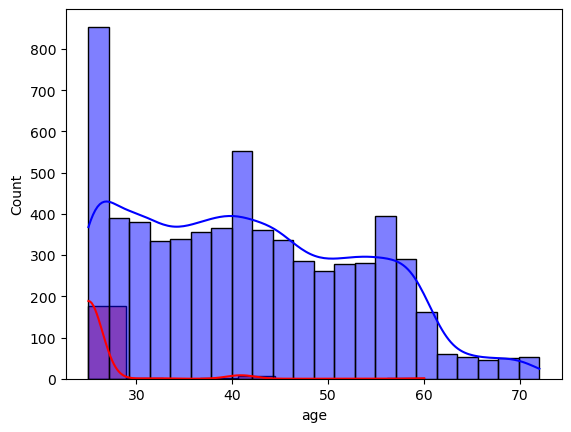

In [94]:
sns.histplot(df_reversed['age'], color= 'red', kde = True)
sns.histplot(df_test_reversed.age, color = 'blue', kde = True)

In [95]:
print((df_reversed.age <= 25).count())

186


In [96]:
# People below the age of 25 are unpredictable

In [97]:
# Solution-1: delete the entries below age 25
# Solution-2 : Segmentation 

# Segmenation: Divide the dataset into multiple sub-datasets and train them separatly.
    